# Transfer Learning

In [1]:
!pip install torchinfo
!pip install torchmetrics

In [2]:
import torch
import torch.nn as nn
from pathlib import Path
import requests
import zipfile
import os
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b2
from torchvision.models import EfficientNet_B2_Weights
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchinfo
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm
import glob
import random
from PIL import Image

## Get data

In [3]:
data_folder = Path('data')
data_folder.mkdir(parents=True, exist_ok=True)
zip_file = data_folder / 'pizza_sushi_steak.zip'

if not zip_file.is_file():
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    with open(zip_file, 'wb') as f:
        f.write(request.content)
    
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(data_folder)

print('Data')
print(os.listdir(data_folder))

print('\nTrain')
print(os.listdir(data_folder / 'train'))
print(os.listdir(data_folder / 'train' / 'sushi'))

print('\nTest')
print(os.listdir(data_folder / 'test'))
print(os.listdir(data_folder / 'test' / 'sushi'))

Data
['pizza_sushi_steak.zip', 'train', 'test', 'model']

Train
['steak', 'pizza', 'sushi']
['377047.jpg', '2017378.jpg', '765684.jpg', '1221830.jpg', '2492146.jpg', '2641778.jpg', '1575445.jpg', '2323548.jpg', '2267190.jpg', '169392.jpg', '1552504.jpg', '2720223.jpg', '390178.jpg', '686426.jpg', '1615453.jpg', '2590819.jpg', '2120573.jpg', '2674024.jpg', '3579071.jpg', '1070104.jpg', '170385.jpg', '2813454.jpg', '2175561.jpg', '3081701.jpg', '1138695.jpg', '2021685.jpg', '148799.jpg', '385154.jpg', '1551817.jpg', '2021381.jpg', '1232045.jpg', '497686.jpg', '3360207.jpg', '200025.jpg', '3737197.jpg', '307738.jpg', '3107839.jpg', '121940.jpg', '2873571.jpg', '3426958.jpg', '821108.jpg', '700405.jpg', '542188.jpg', '1280119.jpg', '93139.jpg', '1214108.jpg', '1209865.jpg', '1129338.jpg', '794647.jpg', '2980779.jpg', '3251688.jpg', '1571146.jpg', '2797464.jpg', '424994.jpg', '2871052.jpg', '929471.jpg', '2574453.jpg', '268990.jpg', '14046.jpg', '855721.jpg', '1957449.jpg', '3004029.jpg', '

## Create Dataset

Number of images in training dataset:  225
Shape of an image:  torch.Size([3, 288, 288])
Range of value in an image: -2.1179039478302 to 2.640000104904175
Classes:  ['pizza', 'steak', 'sushi']


(np.float64(-0.5), np.float64(287.5), np.float64(287.5), np.float64(-0.5))

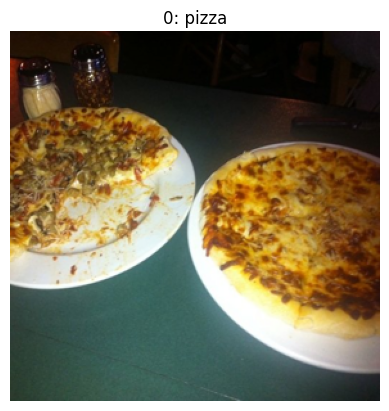

In [4]:
# Create dataset

train_data = ImageFolder(
    root = data_folder / 'train',
    transform = EfficientNet_B2_Weights.IMAGENET1K_V1.transforms()
)

test_data = ImageFolder(
    root = data_folder / 'test',
    transform = EfficientNet_B2_Weights.IMAGENET1K_V1.transforms()
)

# Visualize dataset
image, label = train_data[0]
print('Number of images in training dataset: ', len(train_data))
print('Shape of an image: ', image.shape)
print(f'Range of value in an image: {torch.min(image)} to {torch.max(image)}')
print('Classes: ', train_data.classes)

def denormalize_img(img: torch.Tensor) -> torch.Tensor:
    ch0 = (img[0]*torch.tensor(0.229) + torch.tensor(0.485)).unsqueeze(dim=0)
    ch1 = (img[1]*torch.tensor(0.224) + torch.tensor(0.456)).unsqueeze(dim=0)
    ch2 = (img[2]*torch.tensor(0.225) + torch.tensor(0.406)).unsqueeze(dim=0)
    out = torch.cat((ch0, ch1, ch2), 0)
    return out

plt.imshow(denormalize_img(image).permute(1,2,0))
plt.title(f'{label}: {train_data.classes[label]}')
plt.axis(False)


## Create dataloader

In [5]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

imgs, labels = next(iter(train_dataloader))
print('Number of batches in train: ', len(train_dataloader))
print('Size of an image batch: ', imgs.shape)
print('Size of a label batch: ', labels.shape)

Number of batches in train:  8
Size of an image batch:  torch.Size([32, 3, 288, 288])
Size of a label batch:  torch.Size([32])


## Create a model

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_model(
        device: torch.device,
        is_frozen: bool = True
) -> torch.nn.Module:
    model = efficientnet_b2(weights='DEFAULT').to(device)
    if is_frozen:
        for params in model.parameters():
            params.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=len(train_data.classes), bias=True)
    ).to(device)
    return model

model_0 = get_model(
    device = device,
    is_frozen = True
)

torchinfo.summary(
    model = model_0,
    input_size = (1, 3, 288, 288),
    row_settings=['var_names'],
    col_names = ['input_size', 'output_size', 'num_params', 'trainable']
)

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
EfficientNet (EfficientNet)                                  [1, 3, 288, 288]          [1, 3]                    --                        Partial
├─Sequential (features)                                      [1, 3, 288, 288]          [1, 1408, 9, 9]           --                        False
│    └─Conv2dNormActivation (0)                              [1, 3, 288, 288]          [1, 32, 144, 144]         --                        False
│    │    └─Conv2d (0)                                       [1, 3, 288, 288]          [1, 32, 144, 144]         (864)                     False
│    │    └─BatchNorm2d (1)                                  [1, 32, 144, 144]         [1, 32, 144, 144]         (64)                      False
│    │    └─SiLU (2)                                         [1, 32, 144, 144]         [1, 32, 144, 144]         --         

## Train / Test Loop

In [7]:
# Hyperparameter
EPOCHS = 5
LEARNING_RATE = 1E-3

# utils
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), LEARNING_RATE)
acc_fn = MulticlassAccuracy(num_classes=len(train_data.classes), average='micro').to(device)

# plot utility
plt_epochs = []
plt_train_loss = []
plt_train_acc = []
plt_test_loss = []
plt_test_acc = []

for epoch in range(EPOCHS):

    ep_train_loss = 0
    ep_train_acc = 0
    ep_test_loss = 0
    ep_test_acc = 0

    model_0.train()
    for X, y in tqdm(train_dataloader):
        X, y = X.to(device), y.to(device)
        y_preds = model_0(X)
        train_loss = loss_fn(y_preds, torch.nn.functional.one_hot(y, num_classes=len(train_data.classes)).to(torch.float32))
        train_acc = acc_fn(torch.argmax(y_preds, dim=1), y)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        ep_train_loss += train_loss.item()
        ep_train_acc += train_acc.item()
    
    num_train_batches = len(train_dataloader)
    ep_train_loss /= num_train_batches
    ep_train_acc /= num_train_batches
    
    model_0.eval()
    with torch.inference_mode():
        for X, y in tqdm(test_dataloader):
            X, y = X.to(device), y.to(device)
            y_preds = model_0(X)
            test_loss = loss_fn(y_preds, torch.nn.functional.one_hot(y, num_classes=len(train_data.classes)).to(torch.float32))
            test_acc = acc_fn(torch.argmax(y_preds, dim=1), y)

            ep_test_loss += test_loss.item()
            ep_test_acc += test_acc.item()
    
        num_test_batches = len(test_dataloader)
        ep_test_loss /= num_test_batches
        ep_test_acc /= num_test_batches

    plt_epochs.append(epoch)
    plt_train_loss.append(ep_train_loss)
    plt_train_acc.append(ep_train_acc)
    plt_test_loss.append(ep_test_loss)
    plt_test_acc.append(ep_test_acc)

    print('Epoch: ', epoch)
    print(f'Train Loss: {ep_train_loss:.4f} | Train Acc: {ep_train_acc:.2f}')
    print(f'Test Loss: {ep_test_loss:.4f} | Test Acc: {ep_test_acc:.2f}')




  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  0
Train Loss: 1.0970 | Train Acc: 0.42
Test Loss: 0.9284 | Test Acc: 0.66


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  3
Train Loss: 0.7452 | Train Acc: 0.76
Test Loss: 0.6378 | Test Acc: 0.88


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  4
Train Loss: 0.6137 | Train Acc: 0.89
Test Loss: 0.6176 | Test Acc: 0.90


## Plot Results

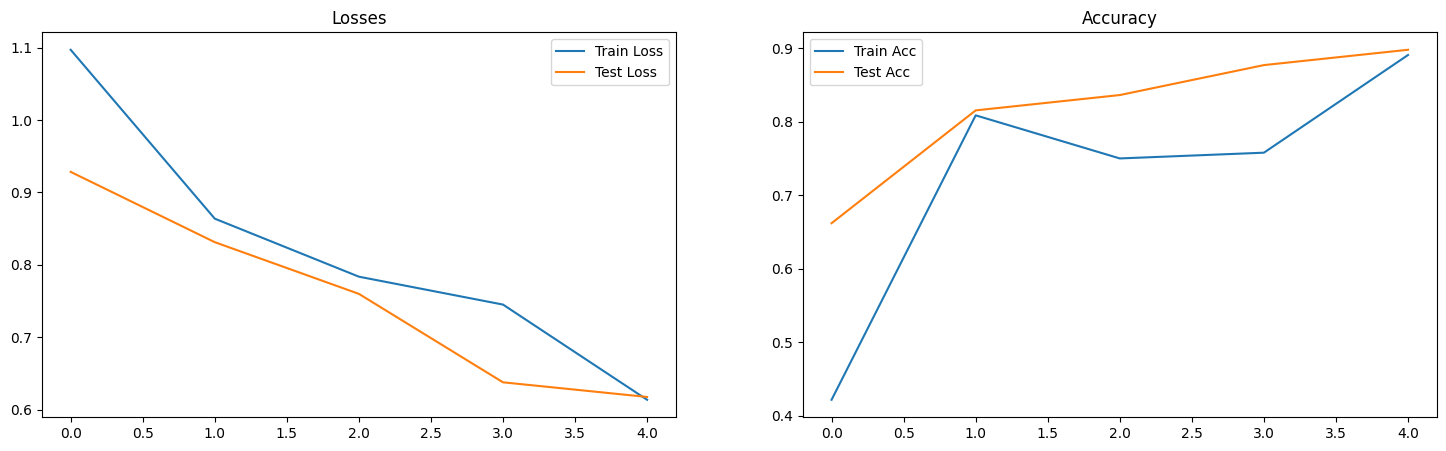

In [8]:
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot(plt_epochs, plt_train_loss, label='Train Loss')
plt.plot(plt_epochs, plt_test_loss, label='Test Loss')
plt.title('Losses')
plt.legend()

plt.subplot(1,2,2)
plt.plot(plt_epochs, plt_train_acc, label='Train Acc')
plt.plot(plt_epochs, plt_test_acc, label='Test Acc')
plt.title('Accuracy')
plt.legend()

## Save and Load model

In [9]:
# Save model
save_folder = data_folder / 'model'
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder / 'model_0.pt'
torch.save(model_0.state_dict(), save_path)

In [10]:
# Load model
loaded_model = get_model(device=device, is_frozen=False)
loaded_model.load_state_dict(torch.load(save_path, weights_only=True))

<All keys matched successfully>

## Make infernce

Text(0.5, 1.0, 'GT: steak | Pred: steak | Probs: 0.6646236181259155')

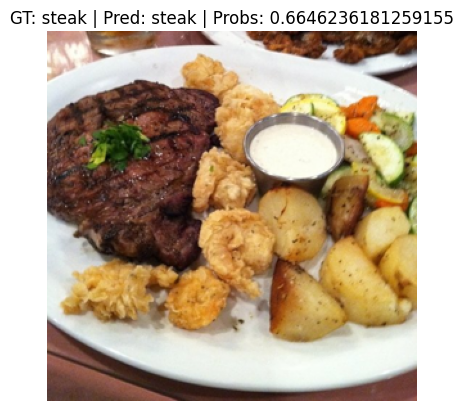

In [11]:
all_test_img_paths = glob.glob(str(data_folder / 'test/*/*.jpg'))
img_path = random.choice(all_test_img_paths)
gt_class = Path(img_path).parent.stem
transform = EfficientNet_B2_Weights.IMAGENET1K_V1.transforms()

transformed_img = transform(Image.open(img_path))
loaded_model.eval()
with torch.inference_mode():
    y_preds = loaded_model(transformed_img.unsqueeze(dim=0).to(device))
    y_probs = torch.softmax(y_preds, dim=1)
    y_label = torch.argmax(y_probs, dim=1).squeeze()
    y_class = train_data.classes[y_label]


plt.imshow(denormalize_img(transformed_img).permute(1,2,0))
plt.axis('off')
plt.title(f'GT: {gt_class} | Pred: {y_class} | Probs: {y_probs.squeeze()[y_label]}')